In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, pickle, warnings

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import norm

In [3]:
plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['axes.facecolor']   = '#1a1d27'
plt.rcParams['text.color']       = '#e0e0e0'
plt.rcParams['axes.labelcolor']  = '#e0e0e0'
plt.rcParams['xtick.color']      = '#9e9e9e'
plt.rcParams['ytick.color']      = '#9e9e9e'
C_BLUE  = '#6366f1'; C_GREEN = '#10b981'
C_AMBER = '#f59e0b'; C_RED   = '#ef4444'

In [4]:
with open('models/best_model.pkl','rb') as f:
    pkg = pickle.load(f)

model      = pkg['model']
model_name = pkg['model_name']
FEATURES   = pkg['features']
TARGET     = pkg['target']
config     = pkg['config']

df = pd.read_csv('C:/Users/HP/Downloads/edunet-IBM AIML project/retail_features.csv', parse_dates=['date'],low_memory=False)
val_end  = pd.to_datetime(pkg['val_end'])
train_end = pd.to_datetime(pkg['train_end'])

test_df  = df[df['date'] > val_end].copy()
train_df = df[df['date'] <= train_end].copy()

X_test = test_df[FEATURES].fillna(0)
y_test = test_df[TARGET]

print(f'Model : {model_name}')
print(f'Test set: {len(test_df):,} rows')
print(f'Period  : {test_df["date"].min().date()} → {test_df["date"].max().date()}')


Model : Ridge
Test set: 3,321 rows
Period  : 2011-08-22 → 2011-12-09


In [5]:
preds = np.maximum(0, model.predict(X_test))

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2   = r2_score(y_test, preds)
mape = np.mean(np.abs((y_test.values - preds) / (y_test.values + 1))) * 100
acc  = max(0, 100 - mape)

print('\n' + '='*55)
print(f'FINAL TEST ACCURACY — {model_name}')
print('(Honest score on data model has NEVER seen)')
print('='*55)
print(f'  R² Score : {r2:.4f}  → explains {r2*100:.1f}% of variance')
print(f'  MAE      : {mae:.2f}  units average error')
print(f'  RMSE     : {rmse:.2f}  units')
print(f'  MAPE     : {mape:.2f}%')
print(f'  Accuracy : {acc:.1f}%')

print('\nMAPE Benchmarks:')
print('< 10% = Excellent | 10-20% = Good | 20-50% = Acceptable | >50% = Poor')



FINAL TEST ACCURACY — Ridge
(Honest score on data model has NEVER seen)
  R² Score : -1021.7754  → explains -102177.5% of variance
  MAE      : 41605.39  units average error
  RMSE     : 45428.30  units
  MAPE     : 1167403.38%
  Accuracy : 0.0%

MAPE Benchmarks:
< 10% = Excellent | 10-20% = Good | 20-50% = Acceptable | >50% = Poor


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(



ACCURACY BY PRODUCT (top 15):
                        description  Accuracy (%)   MAPE (%)  Avg Demand  Records
        60 TEATIME FAIRY CAKE CASES           0.0 1324311.49        35.8    110.0
      ASSORTED COLOUR BIRD ORNAMENT           0.0  759337.80       112.5    110.0
          ASSORTED COLOURS SILK FAN           0.0 1664867.44        21.8    110.0
                BROCADE RING PURSE            0.0 2318624.21        63.1    110.0
COLOUR GLASS T-LIGHT HOLDER HANGING           0.0 1542764.13        31.2    110.0
 CREAM HANGING HEART T-LIGHT HOLDER           0.0  662747.78        86.8    222.0
            JUMBO BAG PINK POLKADOT           0.0  839542.74        72.5    220.0
            JUMBO BAG RED RETROSPOT           0.0  777965.48       156.2    330.0
            LUNCH BAG RED RETROSPOT           0.0  675692.36        41.5    220.0
     MEDIUM CERAMIC TOP STORAGE JAR           0.0 1602085.70        12.6    110.0
  MINI PAINT SET VINTAGE  BOY+ GIRL           0.0 1640353.35       

C:\Users\HP\AppData\Local\Temp\ipykernel_32264\3315002312.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


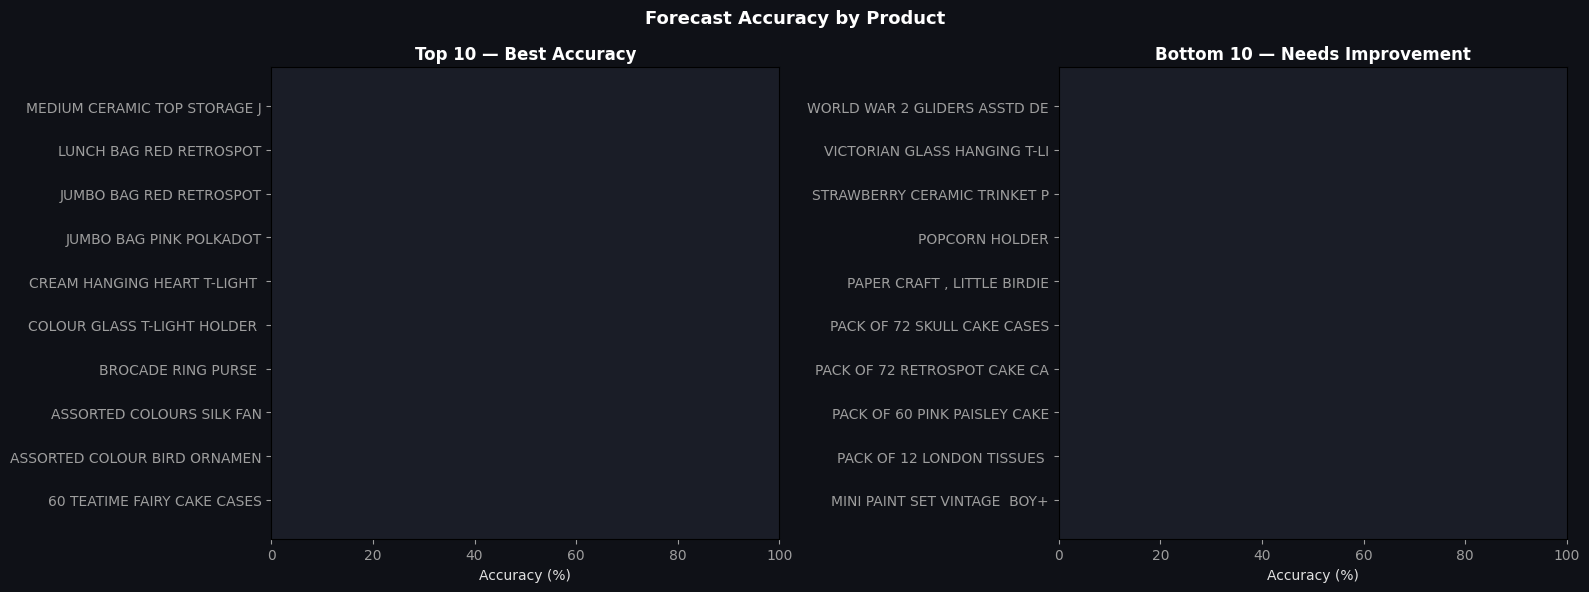

Saved: data/chart_09_accuracy_by_product.png


In [6]:
test_df['predicted'] = preds
test_df['pct_error'] = (np.abs(test_df['demand'] - test_df['predicted'])
                        / (test_df['demand'] + 1) * 100)

prod_acc = (
    test_df.groupby('description')
    .apply(lambda x: pd.Series({
        'Accuracy (%)' : max(0, 100 - x['pct_error'].mean()),
        'MAPE (%)'     : x['pct_error'].mean().round(2),
        'Avg Demand'   : x['demand'].mean().round(1),
        'Records'      : len(x),
    }))
    .sort_values('Accuracy (%)', ascending=False)
    .reset_index()
)

print('\nACCURACY BY PRODUCT (top 15):')
print(prod_acc.head(15).round(2).to_string(index=False))

# Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Forecast Accuracy by Product',
             fontsize=13, fontweight='bold', color='white')

top10 = prod_acc.head(10)
ax1.barh(top10['description'].str[:28], top10['Accuracy (%)'],
         color=C_GREEN, alpha=0.85)
ax1.set_title('Top 10 — Best Accuracy', fontweight='bold', color='white')
ax1.set_xlabel('Accuracy (%)')
ax1.set_xlim(0, 100)

bot10 = prod_acc.tail(10)
ax2.barh(bot10['description'].str[:28], bot10['Accuracy (%)'],
         color=C_RED, alpha=0.85)
ax2.set_title('Bottom 10 — Needs Improvement', fontweight='bold', color='white')
ax2.set_xlabel('Accuracy (%)')
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('data/chart_09_accuracy_by_product.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/chart_09_accuracy_by_product.png')

In [7]:
print('\n' + '='*55)
print('INVENTORY OPTIMIZATION — EOQ MODEL')
print('='*55)

ORDERING_COST     = 50      # £50 per order (shipping + admin)
HOLDING_COST_RATE = 0.25    # 25% of item value per year
SERVICE_LEVEL     = 0.95    # 95% → z = 1.645
LEAD_TIME_DAYS    = 7       # days from order to delivery
z = norm.ppf(SERVICE_LEVEL) # = 1.645

print(f'  Ordering cost     : £{ORDERING_COST}')
print(f'  Holding cost rate : {HOLDING_COST_RATE*100}% / year')
print(f'  Service level     : {SERVICE_LEVEL*100}%  (z = {z:.3f})')
print(f'  Lead time         : {LEAD_TIME_DAYS} days')

# Compute stats from TRAINING data only (not test!)
stats = train_df.groupby(['stockcode','description']).agg(
    avg_daily_demand = ('demand', 'mean'),
    std_daily_demand = ('demand', 'std'),
    avg_price        = ('price',  'mean'),
).reset_index().fillna(0)

stats['annual_demand']     = stats['avg_daily_demand'] * 365
stats['holding_cost_unit'] = stats['avg_price'] * HOLDING_COST_RATE

# EOQ = sqrt( 2DS / H )
stats['EOQ'] = np.sqrt(
    2 * stats['annual_demand'] * ORDERING_COST
    / (stats['holding_cost_unit'] + 0.01)
).round(0)


INVENTORY OPTIMIZATION — EOQ MODEL
  Ordering cost     : £50
  Holding cost rate : 25.0% / year
  Service level     : 95.0%  (z = 1.645)
  Lead time         : 7 days


In [8]:
# Safety Stock = z × σ × sqrt(LT)
stats['safety_stock'] = (
    z * stats['std_daily_demand'] * np.sqrt(LEAD_TIME_DAYS)
).round(0)

# Reorder Point = LT × avg demand + safety stock
stats['reorder_point'] = (
    LEAD_TIME_DAYS * stats['avg_daily_demand'] + stats['safety_stock']
).round(0)

# Max stock level
stats['max_stock']       = (stats['reorder_point'] + stats['EOQ']).round(0)
stats['orders_per_year'] = (stats['annual_demand'] / (stats['EOQ'] + 1)).round(1)

print('\nINVENTORY RECOMMENDATIONS (top 10 by demand):')
cols = ['description','avg_daily_demand','safety_stock',
        'reorder_point','EOQ','max_stock','orders_per_year']
print(stats.nlargest(10,'avg_daily_demand')[cols].round(1).to_string(index=False))


INVENTORY RECOMMENDATIONS (top 10 by demand):
                       description  avg_daily_demand  safety_stock  reorder_point    EOQ  max_stock  orders_per_year
 WORLD WAR 2 GLIDERS ASSTD DESIGNS             144.2        2014.0         3024.0 8455.0    11479.0              6.2
    MEDIUM CERAMIC TOP STORAGE JAR             142.7       14163.0        15162.0 4392.0    19554.0             11.9
CREAM HANGING HEART T-LIGHT HOLDER             134.0         961.0         1899.0 2486.0     4385.0             19.7
           JUMBO BAG RED RETROSPOT             110.0         712.0         1482.0 2588.0     4070.0             15.5
               BROCADE RING PURSE              109.1        2777.0         3541.0 7318.0    10859.0              5.4
   PACK OF 72 RETROSPOT CAKE CASES             109.0         690.0         1453.0 4531.0     5984.0              8.8
     ASSORTED COLOUR BIRD ORNAMENT             101.1         886.0         1593.0 2339.0     3932.0             15.8
                 

In [9]:
print('\n' + '='*55)
print('PROJECTED BUSINESS IMPACT')
print('='*55)

test_revenue      = (test_df['demand'] * test_df['price']).sum()
stockout_loss     = test_revenue * 0.03        # 3% industry avg stockout loss
recovered_rev     = stockout_loss * 0.40       # AI recovers 40% of that
inventory_saving  = test_revenue * 0.05 * 0.15 # 15% less overstock (5% carry cost)
total_benefit     = recovered_rev + inventory_saving

print(f'  Test Period Revenue       : £{test_revenue:>12,.2f}')
print(f'  Stockout Revenue Loss (3%): £{stockout_loss:>12,.2f}')
print(f'  Recovered by AI  (40%)   : £{recovered_rev:>12,.2f}')
print(f'  Inventory Savings        : £{inventory_saving:>12,.2f}')
print(f'  ─────────────────────────────────────────────')
print(f'  TOTAL PROJECTED BENEFIT  : £{total_benefit:>12,.2f}')


PROJECTED BUSINESS IMPACT
  Test Period Revenue       : £  583,563.32
  Stockout Revenue Loss (3%): £   17,506.90
  Recovered by AI  (40%)   : £    7,002.76
  Inventory Savings        : £    4,376.72
  ─────────────────────────────────────────────
  TOTAL PROJECTED BENEFIT  : £   11,379.48


In [12]:
stats.to_csv('C:/Users/HP/Downloads/edunet-IBM AIML project/inventory_optimization.csv', index=False)
test_df.to_csv('C:/Users/HP/Downloads/edunet-IBM AIML project/validation_results.csv', index=False)

metrics_out = {
    'model_name'        : model_name,
    'r2'                : round(r2, 4),
    'mae'               : round(mae, 2),
    'rmse'              : round(rmse, 2),
    'mape'              : round(mape, 2),
    'accuracy_pct'      : round(acc, 1),
    'test_period_start' : str(test_df['date'].min().date()),
    'test_period_end'   : str(test_df['date'].max().date()),
    'projected_benefit' : round(total_benefit, 2),
    'n_features'        : len(FEATURES),
    'n_products'        : df['stockcode'].nunique(),
    'n_countries'       : df['country'].nunique(),
    'total_records'     : len(df),
}
with open('C:/Users/HP/Downloads/edunet-IBM AIML project/metrics.json','w') as f:
    json.dump(metrics_out, f, indent=2)

print('\nSaved: inventory_optimization.csv')
print('Saved: validation_results.csv')
print('Saved: metrics.json')
print('\n' + '='*55)

print('Open app/streamlit_app.py in VS Code next')
print('Run: streamlit run app/streamlit_app.py')
print('='*55)


Saved: inventory_optimization.csv
Saved: validation_results.csv
Saved: metrics.json

Open app/streamlit_app.py in VS Code next
Run: streamlit run app/streamlit_app.py
